# Laboratorio de Fundamentos de Imagen
*Procesamiento Digital de Imágenes — IFTS Nº 24 — 2026*

---

## Sobre esta guía

Esta guía es la continuación directa del trabajo de la Clase 2:
- En `02a` vieron los conceptos: píxeles, resolución, profundidad de bits, modelos de color RGB y HSV.
- En `02b` manipularon una imagen real con código: leyeron coordenadas, extrajeron valores RGB, modificaron canales con el mouse.

Lo que viene ahora es un paso atrás deliberado. Antes de seguir programando, vale la pena preguntarse de dónde vienen las imágenes, qué significa capturar movimiento y qué implica representar una escena continua como una matriz de datos.

**Trabajo en duplas.** Cada grupo elige cómo distribuir las tareas, pero la reflexión debe ser conjunta y el registro debe mostrar que pensaron los dos.

**Formato de entrega libre.** Pueden entregar imágenes comentadas, capturas, un PDF, un video corto, un notebook o una presentación. Lo que importa es que el registro muestre evidencia de las tres actividades y respuestas a al menos tres de las preguntas de reflexión de cada sección. Entrega individual o en dupla según lo acordado en clase.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta_imagen = Path("/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/003/003 - LAB/CAMARA_OSCURA_01.jpeg")

def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen en: {ruta}")
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

imagen_rgb = cargar_rgb(ruta_imagen)

plt.figure(figsize=(8, 6), constrained_layout=True)
plt.imshow(imagen_rgb)
plt.title("Cámara Oscura Original", fontweight="bold", loc="left")
plt.axis("off")
plt.show()

---
## Actividad 1 — La cámara oscura

### Objetivo
Construir el dispositivo más simple capaz de formar una imagen y observar directamente los principios ópticos que subyacen a toda imagen técnica: proyección rectilínea, inversión geométrica, relación entre apertura y nitidez.

### Marco conceptual
Antes de la fotografía, antes de la lente, antes del sensor, existía este mecanismo: un espacio oscuro con un orificio. La luz viaja en línea recta. Cada punto de la escena exterior emite luz en todas direcciones; el orificio selecciona un único rayo por punto y lo proyecta en la pared opuesta. El resultado es una imagen invertida —arriba abajo, izquierda derecha— y continua.

La habitación oscura es el cráneo. El orificio es el ojo. Lo que se proyecta en la pared es lo que el cerebro recibe antes de procesarlo. Abelardo Morell pasó décadas fotografiando este fenómeno a escala de habitaciones enteras. Su trabajo no es nostalgia tecnológica: demuestra que el mecanismo de ver ya existía antes de cualquier aparato, y que ese mecanismo tiene consecuencias matemáticas concretas que hoy operan dentro de cada CNN que entrenamos.

En `02a` estudiaron el **modelo de cámara estenopeica** (*pinhole*) como la base geométrica de cómo un mundo tridimensional se convierte en una imagen plana bidimensional. Esta actividad lo hace concreto: con una caja y un alfiler.

### Materiales
Una caja de cartón cerrada (zapatos, cereales o similar), papel de aluminio o papel negro, cinta adhesiva, un alfiler o aguja, tijeras o cúter.

### Paso a paso

1. Sellá la caja completamente. No debe entrar luz por ninguna ranura.
2. Cubrí el interior de uno de los lados con papel de aluminio o papel negro. Esa es la pantalla donde se proyecta la imagen.
3. En el lado opuesto a la pantalla, hacé un orificio pequeño con el alfiler.
4. Hacé un segundo orificio lateral —lo suficientemente grande para apoyar el ojo y mirar adentro sin que entre luz.
5. Apuntá el orificio principal hacia una escena iluminada y mirá hacia adentro.

**Para el registro:** fotografíen la cámara construida y capturen o dibujen lo que observan adentro. Incluyan al menos una variación (orificio más grande, orificio más pequeño).

### Preguntas de reflexión

- ¿Qué ven? Describí la imagen: ¿está invertida? ¿es nítida o borrosa? ¿es brillante o tenue?
- Probá agrandar el orificio principal. ¿Qué cambia? ¿Y si lo hacés más chico?
- Si la caja no está completamente sellada, ¿qué le pasa a la imagen?
- La imagen en la pantalla es continua —no está dividida en puntos. ¿Qué tendría que pasar para convertirla en una imagen digital? ¿Qué se pierde en esa conversión?
- ¿Qué imágenes puede producir esta cámara y cuáles no? ¿Qué limitaciones tiene el dispositivo?

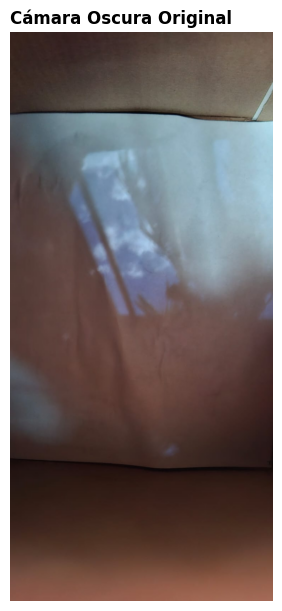

In [13]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta_imagen = Path("/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/003/003 - LAB/CAMARA_OSCURA_01.jpeg")

def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen en: {ruta}")
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

imagen_rgb = cargar_rgb(ruta_imagen)

plt.figure(figsize=(8, 6), constrained_layout=True)
plt.imshow(imagen_rgb)
plt.title("Cámara Oscura Original", fontweight="bold", loc="left")
plt.axis("off")
plt.show()

Actividad 1 — La cámara oscura
1. ¿Qué ven? Describí la imagen: ¿está invertida? ¿es nítida o borrosa? ¿es brillante o tenue?

La imagen capturada es un ventanal que dá a un patio, con un cactus y adornos colgantes.
Al observar el interior de la cámara oscura se forma una imagen proyectada de la escena exterior sobre la pantalla opuesta al orificio. Esa imagen aparece invertida, tanto vertical como horizontalmente: la parte superior del objeto se proyecta abajo y la parte inferior arriba, mientras que la izquierda y la derecha también se invierten. Esto ocurre porque la luz se propaga en línea recta y el orificio permite el paso de rayos luminosos que se cruzan al atravesarlo.

Se realizaron varios intentos, resultando el elegido el que ofrecia un mejor aspecto con un agujero de filtrado de luz pequeño. La imagen obtenida suele ser tenue, ya que por el pequeño orificio entra muy poca luz. En cuanto a la nitidez, depende del tamaño del orificio: cuando el agujero es pequeño, la imagen tiende a verse más definida; cuando es más grande, se vuelve más borrosa.

2. Probá agrandar el orificio principal. ¿Qué cambia? ¿Y si lo hacés más chico?

Al agrandar el orificio principal, entra una mayor cantidad de luz, por lo que la imagen se vuelve más brillante. Sin embargo, pierde nitidez, ya que ingresan más rayos provenientes de distintos puntos de la escena y estos se superponen sobre la pantalla, generando una proyección más borrosa.

En cambio, si el orificio se hace más pequeño, entra menos luz y la imagen se vuelve más oscura o tenue, pero mejora la definición. Esto muestra que existe una relación de compromiso entre brillo y nitidez: un orificio grande favorece la luminosidad, mientras que uno pequeño mejora la precisión de la imagen.

3. Si la caja no está completamente sellada, ¿qué le pasa a la imagen?

Si la caja no está completamente sellada y entra luz por ranuras o aperturas no deseadas, la imagen proyectada pierde contraste y puede volverse muy difícil de ver. Esto sucede porque la cámara oscura necesita que la única luz que ingrese sea la que pasa por el orificio principal. Cuando entra luz adicional, la pantalla se ilumina de manera general y la proyección deja de distinguirse con claridad.

Por eso, el sellado completo de la caja es una condición fundamental para que el dispositivo funcione correctamente.

4. La imagen en la pantalla es continua —no está dividida en puntos. ¿Qué tendría que pasar para convertirla en una imagen digital? ¿Qué se pierde en esa conversión?

Para convertir esa imagen continua en una imagen digital sería necesario muestrearla y discretizarla. Es decir, dividirla en una grilla de pequeñas unidades, equivalentes a los píxeles, y asignar a cada una un valor numérico que represente su intensidad luminosa o su color.

En esa conversión se pierde la continuidad original de la imagen, porque ya no se representa como una superficie continua sino como un conjunto finito de puntos. También puede perderse detalle, dependiendo de la resolución utilizada: si hay pocos píxeles, la representación será menos precisa. Además, en la digitalización suele producirse una cuantificación de los valores de intensidad, lo que implica otra simplificación de la información visual original.

5. ¿Qué imágenes puede producir esta cámara y cuáles no? ¿Qué limitaciones tiene el dispositivo?

La cámara oscura puede producir imágenes de escenas iluminadas y con suficiente contraste, especialmente cuando hay una fuente de luz intensa, como una ventana o un objeto bien iluminado. Puede representar formas, posiciones y relaciones espaciales de los objetos de la escena de manera continua e invertida.

Sin embargo, tiene varias limitaciones. La imagen suele ser poco luminosa, por lo que no funciona bien en ambientes oscuros o con objetos poco iluminados. Tampoco permite captar escenas con gran detalle si el diseño no es preciso, ya que la nitidez depende mucho del tamaño del orificio y de la distancia entre este y la pantalla. Además, no registra ni almacena la imagen por sí sola: solo la proyecta en tiempo real. Para conservarla sería necesario otro dispositivo, como una cámara fotográfica o un sensor digital.

En síntesis, la cámara oscura permite comprender el principio geométrico básico de formación de imágenes, pero presenta limitaciones importantes en brillo, nitidez, estabilidad y registro.

---
## Actividad 2 — Cronofotografía digital

### Objetivo
Descomponer el movimiento en fotogramas discretos, como hizo Marey en el siglo XIX, y reflexionar sobre qué significa convertir el movimiento continuo en datos.

### Marco conceptual
Étienne-Jules Marey no era artista ni fotógrafo en el sentido convencional. Era fisiólogo. Le interesaba medir lo que el ojo no podía ver: la biomecánica del galope, del vuelo, de la marcha humana. Sus placas fotográficas no estaban hechas para ser contempladas —estaban hechas para ser medidas.

Ese gesto —convertir el movimiento en una serie de instantes discretos para operar sobre ellos— es exactamente lo que hace una cámara digital cuando captura video: 24, 30 o 60 fotogramas por segundo, cada uno una matriz de números. El movimiento desaparece. Queda una secuencia de estados.

En `02b` escribieron código que recorre esa matriz de estados píxel por píxel. La cronofotografía es la imagen operativa antes de que existiera la computadora.

### Paso a paso

1. Elegí un objeto en movimiento: una pelota, una mano, agua cayendo, una persona caminando.
2. Decidí qué aspecto del movimiento querés analizar: ¿la trayectoria? ¿la velocidad? ¿el momento de mayor aceleración?
3. Usá el modo ráfaga de la cámara del teléfono. Tratá de mantener la cámara quieta.
4. Seleccioná entre 5 y 10 imágenes que representen fases distintas del movimiento.
5. Disponelas en secuencia en un mismo documento visual —superpuestas, en grilla o en tira.

**Para el registro:** la secuencia de imágenes acompañada de anotaciones sobre qué eligieron analizar y por qué.

### Preguntas de reflexión

- ¿Cuántos fotogramas por segundo capturó la cámara? ¿Qué información sobre el movimiento se perdió entre un fotograma y el siguiente?
- Si superponés todas las imágenes en una sola, ¿qué obtenés? ¿Qué información gana esa imagen compuesta respecto a cada fotograma individual?
- En visión computacional, el seguimiento de objetos (*object tracking*) reconstruye trayectorias automáticamente a partir de fotogramas. ¿Qué tendría que "saber" un sistema para hacer eso? ¿Qué podría fallar?
- Marey producía datos para un sistema de análisis científico con un propósito declarado. ¿Para qué sistemas de análisis producís datos cuando usás la cámara del teléfono? ¿Quién tiene acceso a esas imágenes además de vos?
- Una cámara de reconocimiento facial y la cámara de Marey comparten la misma lógica: descomponer el movimiento en fotogramas para operar sobre ellos. ¿Qué diferencia hay entre medir el galope de un caballo y clasificar el rostro de una persona en un aeropuerto?

1. ¿Cuántos fotogramas por segundo capturó la cámara? ¿Qué información sobre el movimiento se perdió entre un fotograma y el siguiente?

La cantidad de fotogramas por segundo depende de la cámara del dispositivo utilizado. En general, un teléfono celular puede registrar video a 24, 30 o 60 fotogramas por segundo, mientras que el modo ráfaga también captura una sucesión rápida de imágenes fijas. Esto significa que el movimiento continuo no se registra de manera completa, sino como una serie de instantes separados.

Entre un fotograma y el siguiente se pierde toda la información correspondiente a lo que ocurrió en ese intervalo. Es decir, no se conserva el movimiento continuo en sí, sino solo ciertos estados discretos. Por eso, cambios muy rápidos de posición, pequeñas variaciones de velocidad o detalles finos del desplazamiento pueden no quedar registrados con precisión. En otras palabras, la cronofotografía transforma un proceso continuo en una secuencia de muestras.

2. Si superponés todas las imágenes en una sola, ¿qué obtenés? ¿Qué información gana esa imagen compuesta respecto a cada fotograma individual?

Si se superponen todos los fotogramas en una sola imagen, se obtiene una imagen compuesta que muestra varias posiciones sucesivas del objeto en un mismo espacio visual. Esa composición permite observar de forma más clara la trayectoria recorrida, la dirección del movimiento y, en algunos casos, variaciones de velocidad según la separación entre posiciones consecutivas.

La imagen compuesta gana información global sobre el movimiento, porque ya no muestra un único instante aislado sino un recorrido temporal condensado en una sola representación. Cada fotograma individual muestra un estado puntual; en cambio, la superposición permite analizar relaciones entre estados, como continuidad, aceleración, regularidad o cambio de dirección.

3. En visión computacional, el seguimiento de objetos (object tracking) reconstruye trayectorias automáticamente a partir de fotogramas. ¿Qué tendría que “saber” un sistema para hacer eso? ¿Qué podría fallar?

Para realizar seguimiento de objetos, un sistema tendría que poder detectar el objeto de interés en cada fotograma, reconocer que se trata del mismo objeto a lo largo del tiempo y estimar su posición sucesiva. Para ello necesita información visual como forma, color, textura, tamaño relativo o patrones de movimiento. También requiere comparar fotogramas consecutivos y mantener una correspondencia temporal entre ellos.

Sin embargo, este proceso puede fallar por distintas razones. Por ejemplo, el objeto puede moverse muy rápido, salir parcialmente del encuadre, quedar oculto detrás de otro elemento o confundirse con el fondo. También puede haber problemas si la iluminación cambia, si la imagen está borrosa o si aparecen varios objetos similares al mismo tiempo. En esos casos, el sistema puede perder la trayectoria o asignar incorrectamente una identidad.

4. Marey producía datos para un sistema de análisis científico con un propósito declarado. ¿Para qué sistemas de análisis producís datos cuando usás la cámara del teléfono? ¿Quién tiene acceso a esas imágenes además de vos?

Cuando usamos la cámara del teléfono, no solo generamos imágenes para uso personal, sino también datos que pueden ser procesados por múltiples sistemas digitales. Esas imágenes pueden alimentar algoritmos de organización automática, reconocimiento de rostros, clasificación de escenas, mejora de imagen, geolocalización, etiquetado automático o sistemas de recomendación en plataformas y redes sociales.

Además de quien toma la imagen, pueden tener acceso a ella distintas entidades según dónde se almacene o comparta: aplicaciones, servicios en la nube, plataformas de redes sociales, fabricantes de dispositivos o incluso terceros autorizados por condiciones de uso. Por eso, una fotografía digital no es solo un recuerdo visual, sino también un dato que puede circular dentro de infraestructuras técnicas más amplias.

5. Una cámara de reconocimiento facial y la cámara de Marey comparten la misma lógica: descomponer el movimiento en fotogramas para operar sobre ellos. ¿Qué diferencia hay entre medir el galope de un caballo y clasificar el rostro de una persona en un aeropuerto?

La diferencia principal está en el tipo de objeto analizado, el propósito del análisis y sus implicancias éticas y políticas. En el caso de Marey, la cronofotografía se utilizaba para estudiar fenómenos biomecánicos con fines científicos: comprender el movimiento, medirlo y representarlo. El interés estaba puesto en describir un proceso físico observable.

En cambio, el reconocimiento facial aplicado a personas en un aeropuerto no solo mide o registra una secuencia de imágenes, sino que busca identificar, clasificar y eventualmente tomar decisiones sobre individuos concretos. Esto implica cuestiones sensibles como vigilancia, control, privacidad, consentimiento, sesgo algorítmico y riesgo de errores de identificación.

Por lo tanto, aunque ambos sistemas parten de una lógica común —descomponer el movimiento en fotogramas para operar sobre ellos—, no son equivalentes en sus consecuencias. Analizar el galope de un caballo produce conocimiento sobre un fenómeno; clasificar rostros humanos puede afectar derechos, libertades y condiciones de circulación de las personas.

---
## Actividad 3 — Pixelación manual

### Objetivo
Reproducir a mano el proceso de muestreo y cuantificación —los dos pasos que convierten una escena continua en una imagen digital— para entender concretamente qué información se pierde y qué decisiones están implícitas en ese proceso.

### Marco conceptual
En `02a` vieron que digitalizar una imagen implica dos operaciones:
- **Muestreo:** dividir la escena en una cuadrícula de posiciones discretas (píxeles).
- **Cuantificación:** asignar un único valor numérico a la intensidad de cada celda.

Cuando un sensor fotográfico hace esto, opera sobre millones de puntos en microsegundos. Esta actividad propone hacer lo mismo a mano, a baja resolución, para que el proceso se vuelva visible.

### Materiales
Una fotografía impresa (o visible en pantalla), papel cuadriculado o una grilla dibujada, lápices o marcadores de distintos tonos de gris (o de color).

### Paso a paso

1. Elegí una fotografía con zonas de contraste claro: un rostro, un objeto sobre fondo simple, una planta, lo que quieran.
2. Superpongan mentalmente (o físicamente con papel vegetal) una cuadrícula de **8×8** o **16×16** celdas sobre la imagen.
3. Para cada celda, elijan a ojo **un único tono** que represente toda esa área. Están promediando visualmente la información continua en un solo valor.
4. Transcriban ese tono a una grilla en blanco del mismo tamaño —coloreando cada celda con el valor elegido.
5. Comparen la grilla resultante con la imagen original puesta al lado.

*Alternativa digital: si no tienen papel cuadriculado, pueden hacer esta actividad en Google Sheets (cada celda es un píxel) o en cualquier editor de imágenes a baja resolución. El criterio es el mismo: una celda, un valor.*

**Para el registro:** una foto de la grilla terminada junto a la imagen original. Si quieren agregar una segunda versión con una cuadrícula de resolución diferente (4×4 vs 16×16), mejor todavía.

### Preguntas de reflexión

- ¿Qué información de la imagen original se perdió al pixelar? ¿Qué información sobrevivió?
- ¿Hay zonas de la imagen donde la pérdida fue más notoria? ¿Por qué esas zonas y no otras?
- Cuando eligieron el tono de cada celda, tomaron una decisión. ¿Usaron el tono más frecuente? ¿El central? ¿El promedio visual? ¿Cambia el resultado según el criterio?
- Si repiten el ejercicio con una cuadrícula más fina (más celdas), ¿qué pasa con la imagen resultante? ¿Y con el tiempo que lleva hacerlo?
- ¿Qué relación tiene esta actividad con lo que hicieron en `02b` cuando usaron la fórmula `índice = x + y * ancho`?

1. ¿Qué información de la imagen original se perdió? ¿Qué información sobrevivió?

Al pixelar la imagen se pierde principalmente el detalle fino, las transiciones suaves de color y las pequeñas variaciones dentro de cada región. Esto ocurre porque cada celda de la grilla representa un área completa mediante un único valor, eliminando la variabilidad interna.

Sin embargo, se conserva la estructura general de la imagen, como las formas principales, los contrastes grandes entre zonas claras y oscuras y la disposición espacial de los elementos. Es decir, aunque la imagen pierde precisión, mantiene su organización global.

2. ¿Hay zonas donde la pérdida fue más notoria? ¿Por qué?

Sí, la pérdida de información es más evidente en:

- Bordes (contornos)
- Zonas con mucho detalle
- Regiones con cambios bruscos de color o luz

Esto se debe a que dentro de una misma celda pueden coexistir valores muy distintos, y al reducirlos a uno solo se pierde esa variación.

En cambio, en zonas más uniformes (por ejemplo, un fondo liso), la pérdida es menos perceptible porque los valores originales ya eran similares.

3. ¿Qué criterio usaste para elegir el tono? ¿Cambia el resultado?

Para asignar un valor a cada celda se puede usar:

Promedio visual
Valor dominante
Valor central

En general, se utiliza un promedio visual, es decir, una estimación del tono que mejor representa el conjunto de la celda.

Sí, el resultado cambia según el criterio elegido, ya que cada uno implica una forma distinta de resumir la información. Esto demuestra que la cuantificación no es neutra: implica decisiones que afectan la representación final.

4. ¿Qué pasa si usás una cuadrícula más fina?

Si se utiliza una grilla más fina (por ejemplo, pasar de 8×8 a 16×16):

La imagen resultante es más detallada
Se aproxima más a la imagen original
Aumenta el tiempo y el esfuerzo necesario

Esto ocurre porque hay más píxeles disponibles para representar la información, lo que reduce la pérdida de detalle.

Es exactamente lo que pasa con la resolución en imágenes digitales.

5. Relación con índice = x + y * ancho

Esta actividad se relaciona directamente con la forma en que las imágenes se representan en memoria.

Cada celda de la grilla equivale a un píxel
Cada píxel tiene una posición (x, y)
En la computadora, esa posición se transforma en un índice lineal mediante:

índice = x + y * ancho

Esto significa que:

La imagen bidimensional (filas y columnas)
Se guarda como una lista unidimensional

En el ejercicio manual, al recorrer la grilla fila por fila, se está reproduciendo exactamente ese proceso.

---
## Una pregunta que atraviesa las tres actividades

En la cámara oscura, la imagen es continua y nadie la procesa —simplemente existe mientras entra luz.

En la cronofotografía, el movimiento se convierte en una serie de estados discretos.

En la pixelación manual, la escena continua se convierte en una matriz de valores aproximados.

En cada paso, algo se gana y algo se pierde. **¿Qué se gana? ¿Qué se pierde? ¿Y quién decide qué vale la pena conservar?**

---
*Esta pregunta no tiene una respuesta única. Lo que importa es que puedan argumentar su posición con los conceptos que estuvimos trabajando.*

A lo largo de las tres actividades se observa un mismo proceso: la transformación de una realidad continua en una representación discreta que pueda ser analizada, almacenada o procesada.

En la cámara oscura, la imagen existe como un fenómeno continuo: no está fragmentada ni interpretada, simplemente se proyecta mientras hay luz. En este caso no hay pérdida de información dentro del sistema, pero tampoco hay posibilidad de manipulación, registro ni análisis. Lo que se gana es fidelidad al fenómeno físico; lo que se pierde es la capacidad de operar sobre esa imagen.

En la cronofotografía, el movimiento continuo se descompone en una secuencia de fotogramas. Aquí se gana la posibilidad de estudiar el tiempo, comparar estados y analizar trayectorias. Sin embargo, se pierde la continuidad del movimiento: todo lo que ocurre entre un fotograma y el siguiente desaparece. El flujo se convierte en una serie de instantes.

En la pixelación manual, la escena se discretiza en el espacio. Se gana una representación estructurada que puede ser almacenada, transmitida y procesada por sistemas digitales. Pero se pierde detalle, precisión y variaciones internas, ya que cada región se reduce a un único valor.

En conjunto, lo que se gana en estos procesos es operatividad: la posibilidad de medir, comparar, almacenar, transmitir y procesar la información. Lo que se pierde es continuidad, detalle y riqueza del fenómeno original.

La decisión sobre qué conservar no es neutra. Está determinada por el propósito del sistema que utiliza esos datos: no es lo mismo analizar el movimiento de un cuerpo para un estudio científico que reconocer un rostro en un sistema de vigilancia. En cada caso, alguien —un diseñador, un ingeniero, una institución— define qué nivel de detalle es suficiente, qué información es relevante y qué puede descartarse.

En ese sentido, toda imagen digital no es una copia de la realidad, sino una construcción: el resultado de decisiones técnicas y también políticas sobre cómo representar el mundo.